In [14]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import optimize as opt
import pandas as pd

In [1]:
def shifted_cosine(x, xmax, ymax, xmin, ymin):
    return (ymax-ymin) * np.sin(np.pi/2 *(x-xmin)/(xmax-xmin))**2 + ymin

In [6]:
Pockelsdata = pd.read_hdf('20230310_Pockels_calibration.hdf5', key='data')

In [7]:
Pockelsdata

,PC1_setVolt,PC2_setVolt,PC3_setVolt,SCOPE1ZULP:h1p1:rdAmplAv,SCOPE1ZULP:h1p2:rdAmplAv,SCOPE1ZULP:h1p3:rdAmplAv,SCOPE1ZULP:h2p1:rdAmplAv,SCOPE1ZULP:h2p2:rdAmplAv,SCOPE1ZULP:h2p3:rdAmplAv,avglen,ringcurrent
0,0.0,8800.0,8100.0,0.000717,0.001038,0.000926,0.328281,0.326875,0.326641,50.0,124.745292
1,250.0,8800.0,8100.0,0.000693,0.000660,0.000805,0.327539,0.325156,0.326562,50.0,124.628670
2,500.0,8800.0,8100.0,0.000771,0.001077,0.001075,0.329609,0.326367,0.327109,50.0,124.506728
3,750.0,8800.0,8100.0,0.001026,0.001014,0.001518,0.326250,0.327813,0.326797,50.0,124.395417
4,1000.0,8800.0,8100.0,0.002330,0.001683,0.001667,0.330937,0.331016,0.329492,50.0,124.282715
...,...,...,...,...,...,...,...,...,...,...,...
95,8350.0,8800.0,5250.0,0.031484,0.032859,0.032691,0.302187,0.302383,0.302109,50.0,114.896390
96,8350.0,8800.0,5500.0,0.033031,0.033016,0.032305,0.302305,0.300742,0.299805,50.0,114.795617
97,8350.0,8800.0,5750.0,0.033539,0.034586,0.034609,0.298828,0.299766,0.299141,50.0,114.701031
98,8350.0,8800.0,6000.0,0.035422,0.036141,0.036352,0.299141,0.299336,0.301211,50.0,114.605319


In [8]:
PC1 = Pockelsdata.loc[:36]
PC1

,PC1_setVolt,PC2_setVolt,PC3_setVolt,SCOPE1ZULP:h1p1:rdAmplAv,SCOPE1ZULP:h1p2:rdAmplAv,SCOPE1ZULP:h1p3:rdAmplAv,SCOPE1ZULP:h2p1:rdAmplAv,SCOPE1ZULP:h2p2:rdAmplAv,SCOPE1ZULP:h2p3:rdAmplAv,avglen,ringcurrent
0,0.0,8800.0,8100.0,0.000717,0.001038,0.000926,0.328281,0.326875,0.326641,50.0,124.745292
1,250.0,8800.0,8100.0,0.000693,0.000660,0.000805,0.327539,0.325156,0.326562,50.0,124.628670
2,500.0,8800.0,8100.0,0.000771,0.001077,0.001075,0.329609,0.326367,0.327109,50.0,124.506728
3,750.0,8800.0,8100.0,0.001026,0.001014,0.001518,0.326250,0.327813,0.326797,50.0,124.395417
4,1000.0,8800.0,8100.0,0.002330,0.001683,0.001667,0.330937,0.331016,0.329492,50.0,124.282715
5,1250.0,8800.0,8100.0,0.003383,0.003008,0.002741,0.329023,0.325391,0.324492,50.0,124.167285
6,1500.0,8800.0,8100.0,0.004323,0.004177,0.003984,0.324453,0.326445,0.324883,50.0,124.055072
7,1750.0,8800.0,8100.0,0.005023,0.005330,0.004897,0.323906,0.325664,0.324141,50.0,123.947543
8,2000.0,8800.0,8100.0,0.007667,0.007259,0.006107,0.324453,0.323789,0.323320,50.0,123.835453
9,2250.0,8800.0,8100.0,0.008921,0.008589,0.009064,0.324922,0.325977,0.323672,50.0,123.720420


In [9]:
PC2 = Pockelsdata.loc[37:74]
PC2

,PC1_setVolt,PC2_setVolt,PC3_setVolt,SCOPE1ZULP:h1p1:rdAmplAv,SCOPE1ZULP:h1p2:rdAmplAv,SCOPE1ZULP:h1p3:rdAmplAv,SCOPE1ZULP:h2p1:rdAmplAv,SCOPE1ZULP:h2p2:rdAmplAv,SCOPE1ZULP:h2p3:rdAmplAv,avglen,ringcurrent
37,9000.0,8800.0,8100.0,0.041195,0.040281,0.041969,0.317383,0.314375,0.313867,50.0,120.694127
38,8350.0,250.0,8100.0,0.044094,0.043156,0.043141,0.319375,0.321250,0.318359,50.0,120.587999
39,8350.0,500.0,8100.0,0.001413,0.001921,0.001939,0.316914,0.318516,0.316563,50.0,120.480271
40,8350.0,750.0,8100.0,0.000795,0.001384,0.001216,0.317383,0.316250,0.317773,50.0,120.371478
41,8350.0,1000.0,8100.0,0.001765,0.001643,0.001465,0.316133,0.316641,0.314336,50.0,120.269345
42,8350.0,1250.0,8100.0,0.002793,0.002670,0.002473,0.317031,0.317578,0.316406,50.0,120.165757
43,8350.0,1500.0,8100.0,0.003544,0.004017,0.003056,0.319102,0.319883,0.318086,50.0,120.062689
44,8350.0,1750.0,8100.0,0.005109,0.004153,0.004942,0.317578,0.317266,0.316094,50.0,119.958515
45,8350.0,2000.0,8100.0,0.005920,0.006678,0.006055,0.315742,0.312695,0.313203,50.0,119.853503
46,8350.0,2250.0,8100.0,0.007359,0.007992,0.007392,0.316719,0.315195,0.314766,50.0,119.755491


In [12]:
PC1fit = opt.curve_fit(shifted_cosine, PC1['PC1_setVolt'], PC1['SCOPE1ZULP:h1p1:rdAmplAv'], p0=[8500,0.04,0,0])
PC1fit

(array([7.68506085e+03, 4.40150379e-02, 1.59070798e+01, 4.50979034e-04]),
 array([[ 1.57459603e+03,  1.16858288e-03, -1.58151878e+03,
         -3.34719572e-03],
        [ 1.16858288e-03,  2.39337311e-08,  2.58311455e-03,
          6.83193580e-09],
        [-1.58151878e+03,  2.58311455e-03,  5.16476849e+03,
          1.82434022e-02],
        [-3.34719572e-03,  6.83193580e-09,  1.82434022e-02,
          9.58708938e-08]]))

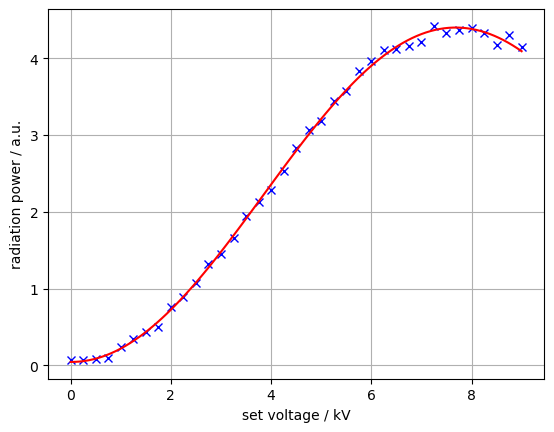

In [17]:
xrange = np.linspace(0,9000,100)
plt.plot( PC1['PC1_setVolt']/1000, PC1['SCOPE1ZULP:h1p1:rdAmplAv']*100, 'bx')
plt.plot(xrange/1000, shifted_cosine(xrange, *PC1fit[0])*100, 'r')
plt.grid()
plt.xlabel('set voltage / kV')
plt.ylabel('radiation power / a.u.')
plt.show()